In [1]:
from pathlib import Path
from IPython.display import HTML, display
css = Path("../../../css/custom.css").read_text(encoding="utf-8")
display(HTML(f"<style>{css}</style>"))

# Chapter 6 — Ensemble Learning Techniques
## Lesson 5: Comparison of Ensemble Methods

**Course:** Introductory Course of Machine Learning (Classical / Non-Deep Learning Track)  
**Chapter count:** 37 chapters  
**Lesson focus:** How to *compare* ensemble families rigorously (accuracy, calibration, robustness, speed, interpretability) and choose the right one for a task.



### Table of Contents
1. Motivation: why “comparison” is a separate skill  
2. A taxonomy of ensemble methods  
3. Theory: why ensembles work (bias–variance, correlation, margins)  
4. Evaluation protocol: fair comparison without leakage  
5. Hands-on comparisons (multiple datasets)  
   - Classification: Iris, Diabetes, Drug200  
   - Regression: House Prices, Salaries  
6. Beyond accuracy: calibration, uncertainty, robustness, and cost  
7. Practical decision matrix: when to use what  
8. Exercises



## 1) Motivation: why “comparison” is a separate skill

Ensembles are not a single algorithm. They are **design patterns** that combine multiple predictors:

- **Bagging**: reduce variance by averaging many “noisy but unbiased-ish” models trained on resampled data.
- **Random forests / ExtraTrees**: bagging + injected randomness in feature selection (and/or splits) to reduce correlation.
- **Boosting**: reduce bias (and sometimes variance) by building an additive model stage-by-stage.
- **Voting / Averaging**: combine *different* model families to hedge risk and reduce error correlation.
- **Stacking**: learn a *meta-model* that optimally combines base models.

A rigorous comparison must go beyond a single score. In practice, you compare methods across:

1. **Predictive performance** on the target metric (accuracy, AUROC, RMSE, …)
2. **Calibration** (are predicted probabilities reliable?)
3. **Stability** (variance across train splits, sensitivity to noise/outliers)
4. **Compute** (training time, inference latency, memory)
5. **Interpretability** (global + local explanations, feature importance reliability)
6. **Operational constraints** (streaming updates, missing values, sparse/categorical features)

This lesson builds a principled framework and then tests it empirically on multiple datasets from your repository.



## 2) A taxonomy of ensemble methods

Let $\mathcal{D} = \{(x_i, y_i)\}_{i=1}^n$ be the training set and $\hat{f}_m$ denote the $m$-th base learner.

### 2.1 Bagging family

**Bootstrap aggregating (bagging)** trains base models on bootstrap samples $\mathcal{D}^{(m)}$ and averages:

- Regression: $$\hat{f}_{\text{bag}}(x) = \frac{1}{M}\sum_{m=1}^M \hat{f}_m(x)$$
- Classification (probabilities): $$\hat{p}_{\text{bag}}(y=k\mid x)=\frac{1}{M}\sum_{m=1}^M \hat{p}_m(y=k\mid x)$$

A key objective: **reduce variance** by averaging *weakly correlated* predictors.

### 2.2 Random Forests (RF)

Random Forests add randomness beyond bootstrapping:
- feature subsampling at each split (typically $\sqrt{d}$ for classification, $d/3$ for regression)
- optionally, further randomization in split thresholds (implementation-dependent)

RF tends to be a strong default for tabular data.

### 2.3 ExtraTrees (Extremely Randomized Trees)

ExtraTrees inject even more randomness:
- often no bootstrap (use full dataset)
- random split thresholds for candidate features, choose best among random thresholds

This can reduce correlation further and sometimes improves generalization; it may also increase bias.

### 2.4 Boosting family (AdaBoost, Gradient Boosting)

Boosting builds an **additive model**:
$$F_M(x) = \sum_{m=1}^M \gamma_m h_m(x)$$

- **AdaBoost** reweights samples based on past mistakes (exponential loss view).
- **Gradient boosting** performs stage-wise functional gradient descent on a chosen loss.

Boosting often wins on accuracy but can be sensitive to noise and requires careful tuning.

### 2.5 Voting and Stacking

- **Voting**: combine heterogeneous models with fixed weights.
- **Stacking**: learn weights via a meta-learner using out-of-fold predictions (to avoid leakage).

### 2.6 Two diagrams only — one taxonomy, one evaluation pipeline

Below is a compact view of how these families relate.

```mermaid
flowchart TD
  A[Ensembles] --> B[Bagging and Randomization]
  A --> C[Boosting and Additive Modeling]
  A --> D[Model Combination]
  B --> B1[BaggingClassifier and Regressor]
  B --> B2[RandomForest]
  B --> B3[ExtraTrees]
  C --> C1[AdaBoost]
  C --> C2[GradientBoosting]
  C --> C3[HistGradientBoosting]
  D --> D1[Voting hard or soft]
  D --> D2[Stacking meta learner]
```



## 3) Theory: why ensembles work

### 3.1 Bias–variance decomposition (regression, squared loss)

Assume a regression setup:
$$y = f^*(x) + \varepsilon,\qquad \mathbb{E}[\varepsilon\mid x]=0,\ \ \mathbb{V}[\varepsilon\mid x]=\sigma_\varepsilon^2$$

For an estimator $\hat{f}(x)$ learned from a random sample $\mathcal{D}$, the mean squared error at a fixed $x$ is:
$$\mathbb{E}\big[(\hat{f}(x)-y)^2\big] = \underbrace{\big(\mathbb{E}[\hat{f}(x)]-f^*(x)\big)^2}_{\text{bias}^2}
+ \underbrace{\mathbb{V}[\hat{f}(x)]}_{\text{variance}}
+ \underbrace{\sigma_\varepsilon^2}_{\text{noise}}$$

Ensembles often reduce the variance term.

### 3.2 Key lemma: averaging reduces variance (if models are not perfectly correlated)

Let $Z_1,\dots,Z_M$ be random variables with $\mathbb{E}[Z_m]=\mu$, $\mathbb{V}[Z_m]=\sigma^2$ and pairwise correlation $\rho$:
$$\text{Corr}(Z_i,Z_j)=\rho\quad \text{for}\ i\neq j$$

Define the average $\bar{Z} = \frac{1}{M}\sum_{m=1}^M Z_m$. Then
$$\mathbb{V}[\bar{Z}] = \sigma^2\left(\rho + \frac{1-\rho}{M}\right)$$

**Proof.**  
Use $\mathbb{V}[\sum_m Z_m] = \sum_m \mathbb{V}[Z_m] + 2\sum_{i<j}\text{Cov}(Z_i,Z_j)$.  
Here $\text{Cov}(Z_i,Z_j)=\rho\sigma^2$. Therefore:
$$\mathbb{V}\left[\sum_{m=1}^M Z_m\right] = M\sigma^2 + 2\binom{M}{2}\rho\sigma^2
= M\sigma^2 + M(M-1)\rho\sigma^2$$
Divide by $M^2$ to get:
$$\mathbb{V}[\bar{Z}] = \sigma^2\left(\rho + \frac{1-\rho}{M}\right)$$
$\blacksquare$

**Interpretation.**
- If $\rho=1$ (perfect correlation), averaging does nothing.
- If $\rho=0$, variance shrinks by $1/M$.
- Ensembles try to reduce $\rho$ via resampling and randomness.

### 3.3 Majority vote, margins, and classification intuition

For binary classification with labels $y\in\{-1,+1\}$ and base classifiers $h_m(x)\in\{-1,+1\}$, the majority vote is:
$$H(x)=\text{sign}\left(\sum_{m=1}^M h_m(x)\right)$$

Define the **margin**:
$$\text{margin}(x,y)=\frac{1}{M}\sum_{m=1}^M \mathbb{1}\{h_m(x)=y\} - \max_{k\neq y}\frac{1}{M}\sum_{m=1}^M \mathbb{1}\{h_m(x)=k\}$$

Ensembles work by pushing margins away from zero:
- Bagging reduces variance in unstable learners (trees), improving margins.
- Boosting focuses on hard points, often increasing margins but risking overfitting to noise.

### 3.4 Boosting as additive modeling (gradient view)

Consider minimizing empirical risk:
$$\min_{F\in\mathcal{F}}\ \ \sum_{i=1}^n \ell(y_i, F(x_i))$$

Gradient boosting constructs $F_m$ iteratively:
1) Start with $F_0(x)=\arg\min_c \sum_i \ell(y_i,c)$  
2) At stage $m$, compute pseudo-residuals:
$$r_{im} = -\left.\frac{\partial \ell(y_i, F(x_i))}{\partial F(x_i)}\right|_{F=F_{m-1}}$$
3) Fit a base learner $h_m$ to predict $r_{im}$ from $x_i$  
4) Line-search step size $\gamma_m$ and update:
$$F_m(x) = F_{m-1}(x) + \nu\,\gamma_m h_m(x)$$

Here $\nu\in(0,1]$ is the learning rate (“shrinkage”).

This is why boosting can be extremely powerful: it is *optimization in function space*.



## 4) Evaluation protocol: fair comparison without leakage

Comparing ensembles incorrectly is extremely common. The most frequent failure modes:

- **Leakage**: preprocessing fit on all data before CV.
- **Non-comparable splits**: different random splits per model.
- **Wrong metrics**: using accuracy only for imbalanced data; ignoring calibration for probabilistic decisions.
- **Hyperparameter overfitting**: tuning on the test set or reusing validation data improperly.

### 4.1 A clean protocol (recommended)

1. Decide a *single* data split strategy (e.g., StratifiedKFold with fixed random_state).
2. Use a **Pipeline** so that preprocessing is inside CV:
   - imputation, scaling, encoding, feature selection, model
3. Evaluate multiple metrics:
   - Classification: accuracy, F1 (macro), log loss (+ calibration metrics if needed)
   - Regression: MAE, RMSE, $R^2$
4. Track compute:
   - fit time, score time
5. If doing stacking, **use out-of-fold predictions** for training the meta-learner (scikit-learn handles this).

### 4.2 One diagram: evaluation pipeline

```mermaid
flowchart LR
  A[Raw CSV] --> B[Train/CV Split]
  B --> C[Pipeline: preprocess + model]
  C --> D[Cross-validated metrics]
  D --> E[Model comparison table]
  D --> F[Calibration and reliability checks]
  D --> G[Runtime and stability]
```


In [2]:
# Core scientific stack
import numpy as np
import pandas as pd

# Modeling + evaluation
from sklearn.model_selection import StratifiedKFold, KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, brier_score_loss
from sklearn.inspection import permutation_importance

# Ensembles
from sklearn.ensemble import (BaggingClassifier, RandomForestClassifier, ExtraTreesClassifier,
                              AdaBoostClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier,
                              VotingClassifier, StackingClassifier,
                              BaggingRegressor, RandomForestRegressor, ExtraTreesRegressor,
                              AdaBoostRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor,
                              VotingRegressor, StackingRegressor)

# Base learners
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.linear_model import LogisticRegression, Ridge

# Visualization
import matplotlib.pyplot as plt

from pathlib import Path

RANDOM_STATE = 7
np.random.seed(RANDOM_STATE)

def load_csv(rel_path: str) -> pd.DataFrame:
    """Load CSV using the repository's relative path conventions."""
    p = Path(rel_path)
    if not p.exists():
        raise FileNotFoundError(
            f"File not found: {p}.\n"
            "Make sure you run this notebook from Tutorials/English/Chapter6/ (or Persian equivalent)\n"
            "and that Datasets/ and css/ folders exist at the expected relative paths."
        )
    return pd.read_csv(p)

def split_features_target(df: pd.DataFrame, target_col: str):
    X = df.drop(columns=[target_col])
    y = df[target_col]
    return X, y

def make_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    """Column-wise preprocessing: impute + scale numeric, impute + one-hot encode categorical."""
    num_cols = X.select_dtypes(include=["number"]).columns.tolist()
    cat_cols = [c for c in X.columns if c not in num_cols]

    numeric = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])
    categorical = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])

    return ColumnTransformer(
        transformers=[
            ("num", numeric, num_cols),
            ("cat", categorical, cat_cols)
        ],
        remainder="drop",
        verbose_feature_names_out=False
    )

print("Setup complete.")

Setup complete.



## 5) Hands-on comparison on multiple datasets

We will run **three classification** and **two regression** case studies.  
Datasets are loaded from your repository using relative paths like:

- `"../../../Datasets/Classification/iris.csv"`
- `"../../../Datasets/Regression/house-prices.csv"`

### Important notes

- Not all datasets have the same schema. Some are purely numeric (Iris), some have categorical columns (Drug200).
- For fairness, we will use **pipelines** so preprocessing is done *inside cross-validation*.
- We will keep hyperparameters modest to highlight method behavior rather than heavy tuning.

We start by loading datasets and inspecting their top rows.


In [3]:
# Load multiple datasets (we intentionally use several different datasets, not only one)

df_iris = load_csv("../../../Datasets/Classification/iris.csv")
df_diabetes = load_csv("../../../Datasets/Classification/diabetes.csv")
df_drug = load_csv("../../../Datasets/Classification/drug200.csv")

df_house = load_csv("../../../Datasets/Regression/house-prices.csv")
df_salaries = load_csv("../../../Datasets/Regression/salaries.csv")

display(df_iris.head())
display(df_diabetes.head())
display(df_drug.head())

display(df_house.head())
display(df_salaries.head())

,sepal_length,sepal_width,petal_length,petal_width,classification
0,5.4,3.7,1.5,0.2,Iris-setosa
1,4.8,3.4,1.6,0.2,Iris-setosa
2,4.8,3.0,1.4,0.1,Iris-setosa
3,4.3,3.0,1.1,0.1,Iris-setosa
4,5.8,4.0,1.2,0.2,Iris-setosa


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,classification
0,6,148,72,35,0,33.6,0.627,50,Diabetic
1,1,85,66,29,0,26.6,0.351,31,Non-Diabetic
2,8,183,64,0,0,23.3,0.672,32,Diabetic
3,1,89,66,23,94,28.1,0.167,21,Non-Diabetic
4,0,137,40,35,168,43.1,2.288,33,Diabetic


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


,Home,Price,SqFt,Bedrooms,Bathrooms,Offers,Brick,Neighborhood
0,1,114300,1790,2,2,2,No,East
1,2,114200,2030,4,2,3,No,East
2,3,114800,1740,3,2,1,No,East
3,4,94700,1980,3,2,3,No,East
4,5,119800,2130,3,3,3,No,East


,Name,Age,Job,Salary
0,Kevin Sanders,24,Software Engineer,7300
1,Lisa Mills,26,High School Teacher,6100
2,Donna Allison,27,Dentist,12700
3,Michael Schmitt,43,Dentist,17500
4,Lisa Shaffer,31,Accountant,7400



### 5.1 Classification benchmark: what we compare

We compare representatives from major ensemble families:

**Bagging / Randomization**
- Bagging + decision trees
- RandomForest
- ExtraTrees

**Boosting**
- AdaBoost (tree stumps or shallow trees)
- GradientBoosting
- HistGradientBoosting (fast histogram-based implementation)

**Combination**
- Voting (heterogeneous models)
- Stacking (meta-learner on out-of-fold predictions)

#### Metrics
For classification, we will compute:
- **accuracy** (easy baseline)
- **F1-macro** (more robust to imbalance/multiclass)
- **log loss** (quality of probabilities)

We also record mean fit/score times to capture compute costs.


In [4]:
def classification_models():
    # Base tree
    tree = DecisionTreeClassifier(max_depth=None, random_state=RANDOM_STATE)
    stump = DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE)

    models = {
        "Bagging(Tree)": BaggingClassifier(
            estimator=tree, n_estimators=200, max_samples=0.8, max_features=1.0,
            bootstrap=True, random_state=RANDOM_STATE, n_jobs=-1
        ),
        "RandomForest": RandomForestClassifier(
            n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1,
            max_depth=None, min_samples_leaf=1
        ),
        "ExtraTrees": ExtraTreesClassifier(
            n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1,
            max_depth=None, min_samples_leaf=1
        ),
        "AdaBoost(Stumps)": AdaBoostClassifier(
            estimator=stump, n_estimators=400, learning_rate=0.5, random_state=RANDOM_STATE
        ),
        "GradientBoosting": GradientBoostingClassifier(
            random_state=RANDOM_STATE, n_estimators=300, learning_rate=0.05, max_depth=3
        ),
        "HistGradientBoosting": HistGradientBoostingClassifier(
            random_state=RANDOM_STATE, max_depth=6, learning_rate=0.05, max_iter=300
        ),
    }

    lr = LogisticRegression(max_iter=2000, solver="lbfgs")
    rf_small = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
    gbdt = GradientBoostingClassifier(random_state=RANDOM_STATE, n_estimators=200, learning_rate=0.05, max_depth=3)

    models["Voting(soft)"] = VotingClassifier(
        estimators=[("lr", lr), ("rf", rf_small), ("gb", gbdt)],
        voting="soft"
    )
    models["Stacking"] = StackingClassifier(
        estimators=[("lr", lr), ("rf", rf_small), ("gb", gbdt)],
        final_estimator=LogisticRegression(max_iter=2000),
        stack_method="predict_proba",
        passthrough=False
    )
    return models

def evaluate_classification(df, target_col: str, task_name: str):
    X, y = split_features_target(df, target_col)
    pre = make_preprocessor(X)
    models = classification_models()
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    scoring = {"acc": "accuracy", "f1_macro": "f1_macro", "neg_log_loss": "neg_log_loss"}

    rows = []
    for name, model in models.items():
        pipe = Pipeline([("pre", pre), ("model", model)])
        out = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=-1)
        rows.append({
            "task": task_name,
            "model": name,
            "acc_mean": float(np.mean(out["test_acc"])),
            "acc_std": float(np.std(out["test_acc"])),
            "f1_macro_mean": float(np.mean(out["test_f1_macro"])),
            "log_loss_mean": float(-np.mean(out["test_neg_log_loss"])),
            "fit_time_mean": float(np.mean(out["fit_time"])),
            "score_time_mean": float(np.mean(out["score_time"])),
        })

    res = pd.DataFrame(rows).sort_values(["task", "acc_mean"], ascending=[True, False])
    display(res)
    return res

res_iris = evaluate_classification(df_iris, target_col="classification", task_name="Iris (multiclass)")
res_diabetes = evaluate_classification(df_diabetes, target_col="classification", task_name="Diabetes (binary)")
res_drug = evaluate_classification(df_drug, target_col="Drug", task_name="Drug200 (multiclass)")

,task,model,acc_mean,acc_std,f1_macro_mean,log_loss_mean,fit_time_mean,score_time_mean
7,Iris (multiclass),Stacking,0.960000,0.024944,0.959832,0.124096,15.319685,0.271559
2,Iris (multiclass),ExtraTrees,0.953333,0.033993,0.953250,0.095244,0.995299,0.298439
6,Iris (multiclass),Voting(soft),0.953333,0.033993,0.953115,0.110992,2.342638,0.219702
0,Iris (multiclass),Bagging(Tree),0.946667,0.040000,0.946533,0.098683,0.902968,0.190023
1,Iris (multiclass),RandomForest,0.946667,0.040000,0.946533,0.104178,1.331542,0.279531
3,Iris (multiclass),AdaBoost(Stumps),0.946667,0.033993,0.946330,0.106327,1.452777,0.258174
4,Iris (multiclass),GradientBoosting,0.946667,0.026667,0.946432,0.665412,2.049663,0.023441
5,Iris (multiclass),HistGradientBoosting,0.946667,0.033993,0.946465,0.412039,0.584048,0.085140


,task,model,acc_mean,acc_std,f1_macro_mean,log_loss_mean,fit_time_mean,score_time_mean
0,Diabetes (binary),Bagging(Tree),0.773415,0.028217,0.743199,0.496263,1.874557,0.204458
2,Diabetes (binary),ExtraTrees,0.770877,0.036966,0.734775,0.488449,1.469314,0.351913
1,Diabetes (binary),RandomForest,0.768212,0.024410,0.735712,0.485484,1.859399,0.325617
7,Diabetes (binary),Stacking,0.766947,0.020911,0.727512,0.474231,19.719163,0.247122
6,Diabetes (binary),Voting(soft),0.765631,0.024283,0.727585,0.465513,2.358305,0.201823
4,Diabetes (binary),GradientBoosting,0.759078,0.030210,0.721651,0.508913,1.542324,0.025321
5,Diabetes (binary),HistGradientBoosting,0.740879,0.033663,0.709233,0.651270,0.700101,0.057012
3,Diabetes (binary),AdaBoost(Stumps),0.735685,0.027098,0.702726,0.687302,2.646074,0.368412


,task,model,acc_mean,acc_std,f1_macro_mean,log_loss_mean,fit_time_mean,score_time_mean
0,Drug200 (multiclass),Bagging(Tree),0.990,0.012247,0.984570,0.020663,0.933535,0.222588
1,Drug200 (multiclass),RandomForest,0.990,0.012247,0.984570,0.112362,1.370779,0.365666
5,Drug200 (multiclass),HistGradientBoosting,0.990,0.012247,0.985586,0.068186,1.169535,0.304605
6,Drug200 (multiclass),Voting(soft),0.990,0.012247,0.984570,0.126154,4.195474,0.247747
4,Drug200 (multiclass),GradientBoosting,0.985,0.012247,0.976951,0.218378,4.170845,0.044336
7,Drug200 (multiclass),Stacking,0.985,0.012247,0.976951,0.092041,30.009397,0.373288
2,Drug200 (multiclass),ExtraTrees,0.950,0.035355,0.927406,0.211835,0.946781,0.336281
3,Drug200 (multiclass),AdaBoost(Stumps),0.835,0.020000,0.519251,0.438971,2.253393,0.318289



### 5.2 Calibration check (binary): reliability and Brier score

Accuracy can be misleading when decisions depend on **probabilities** (risk scoring, thresholding, expected utility).
A classifier is **well-calibrated** if:
$$\mathbb{P}(Y=1 \mid \hat{p}(X)=p) \approx p$$

A simple scalar summary is the **Brier score** (binary):
$$\text{Brier} = \frac{1}{n}\sum_{i=1}^n \big(\hat{p}_i - y_i\big)^2$$

Lower is better.

Below we do a train/test split on the Diabetes dataset and compare probability calibration for a few ensembles.  
(We keep this separate from CV to keep the plotting code straightforward.)


Class balance: {0: np.int64(500), 1: np.int64(268)}


C:\Users\LENOVO.PIESC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


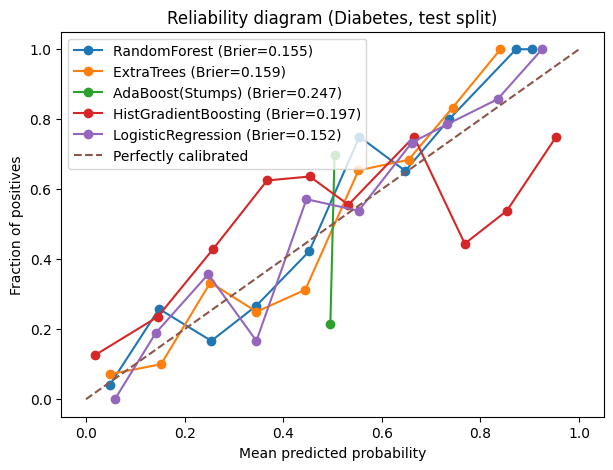

In [5]:
from sklearn.calibration import calibration_curve

X_d, y_d = split_features_target(df_diabetes, "classification")

# Diabetes labels are strings like "Diabetic" and "Non-Diabetic".
# IMPORTANT: avoid substring bugs ("non-diabetic" contains "diabetic").
if y_d.dtype == object:
    y_d_clean = y_d.astype(str).str.strip().str.lower()
    y_d_bin = (y_d_clean == "diabetic").astype(int)
else:
    # If numeric, map the larger value to 1 (common convention)
    y_d_bin = (y_d != y_d.min()).astype(int)

# Sanity check
print("Class balance:", dict(pd.Series(y_d_bin).value_counts()))

X_train, X_test, y_train, y_test = train_test_split(
    X_d, y_d_bin, test_size=0.25, random_state=RANDOM_STATE, stratify=y_d_bin
)

pre = make_preprocessor(X_train)

candidates = {
    "RandomForest": RandomForestClassifier(n_estimators=600, random_state=RANDOM_STATE, n_jobs=-1),
    "ExtraTrees": ExtraTreesClassifier(n_estimators=600, random_state=RANDOM_STATE, n_jobs=-1),
    "AdaBoost(Stumps)": AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
        n_estimators=400, learning_rate=0.5, random_state=RANDOM_STATE
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        random_state=RANDOM_STATE, max_depth=6, learning_rate=0.05, max_iter=400
    ),
    "LogisticRegression": LogisticRegression(max_iter=2000)
}

plt.figure(figsize=(7, 5))
for name, model in candidates.items():
    pipe = Pipeline([("pre", pre), ("model", model)])
    pipe.fit(X_train, y_train)
    proba_full = pipe.predict_proba(X_test)
    # If a model ends up with a single probability column (edge cases), handle gracefully.
    proba = proba_full[:, 1] if proba_full.shape[1] > 1 else proba_full[:, 0]
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10, strategy="uniform")
    plt.plot(mean_pred, frac_pos, marker="o", label=f"{name} (Brier={brier_score_loss(y_test, proba):.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Perfectly calibrated")
plt.title("Reliability diagram (Diabetes, test split)")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.legend()
plt.show()


## 6) Beyond accuracy: robustness, speed, and interpretability

### 6.1 Robustness to noise and outliers

- **Bagging/RF/ExtraTrees** are often robust because each tree sees a different view of data. However, if labels are very noisy, deep trees can still overfit locally.
- **Boosting** can be more sensitive to mislabeled samples because it focuses on hard points. Regularization (learning_rate, early stopping, subsampling, depth constraints) is crucial.

A useful mental model:
- Bagging fights **variance** (instability).
- Boosting fights **bias** (underfitting), but may increase variance if pushed too far.

### 6.2 Compute: training vs inference

Roughly:
- RF/ExtraTrees scale well with parallelism ($M$ trees can be trained in parallel).
- Classic GradientBoosting is sequential (each stage depends on previous), so less parallel.
- HistGradientBoosting is faster on large tabular datasets due to histogram binning and optimized split search.

### 6.3 Interpretability and feature importance

Tree ensembles provide:
- **impurity-based importance** (fast but can be biased toward high-cardinality features)
- **permutation importance** (more reliable but slower)

For stacking/voting, interpretability becomes “ensemble-of-ensembles” and explanations should be treated carefully.

We illustrate permutation importance for a tree ensemble below.


Test accuracy: 0.974


,feature,importance_mean,importance_std
2,petal_length,0.259211,0.066717
3,petal_width,0.114474,0.035575
1,sepal_width,0.000000,0.000000
0,sepal_length,0.000000,0.000000


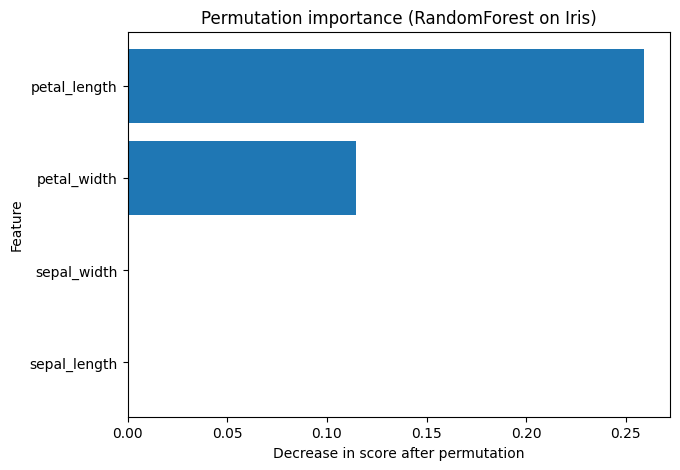

In [6]:
X, y = split_features_target(df_iris, "classification")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

pre = make_preprocessor(X_train)
rf = RandomForestClassifier(n_estimators=600, random_state=RANDOM_STATE, n_jobs=-1)

pipe = Pipeline([("pre", pre), ("model", rf)])
pipe.fit(X_train, y_train)

acc = accuracy_score(y_test, pipe.predict(X_test))
print(f"Test accuracy: {acc:.3f}")

imp = permutation_importance(pipe, X_test, y_test, n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1)

feature_names = pipe.named_steps["pre"].get_feature_names_out()
imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": imp.importances_mean,
    "importance_std": imp.importances_std
}).sort_values("importance_mean", ascending=False)

display(imp_df.head(15))

plt.figure(figsize=(7, 5))
top = imp_df.head(10)
plt.barh(top["feature"][::-1], top["importance_mean"][::-1])
plt.title("Permutation importance (RandomForest on Iris)")
plt.xlabel("Decrease in score after permutation")
plt.ylabel("Feature")
plt.show()


## 7) Regression comparison: ensembles for continuous targets

Ensemble ideas extend naturally to regression. We will compare:

- BaggingRegressor(Tree)
- RandomForestRegressor
- ExtraTreesRegressor
- AdaBoostRegressor
- GradientBoostingRegressor
- HistGradientBoostingRegressor
- VotingRegressor (heterogeneous)
- StackingRegressor (meta-learner)

### Metrics
- MAE: $$\text{MAE}=\frac{1}{n}\sum_{i=1}^n |y_i-\hat{y}_i|$$
- RMSE: $$\text{RMSE}=\sqrt{\frac{1}{n}\sum_{i=1}^n (y_i-\hat{y}_i)^2}$$
- $R^2$: $$R^2 = 1 - \frac{\sum_i (y_i-\hat{y}_i)^2}{\sum_i (y_i-\bar{y})^2}$$

We will run on two datasets with different structure:
- **House Prices** (mixed numeric + categorical)
- **Salaries** (mostly categorical + small scale)


In [7]:
def regression_models():
    tree = DecisionTreeRegressor(random_state=RANDOM_STATE)
    shallow = DecisionTreeRegressor(max_depth=3, random_state=RANDOM_STATE)

    models = {
        "Bagging(Tree)": BaggingRegressor(
            estimator=tree, n_estimators=300, max_samples=0.8, bootstrap=True, random_state=RANDOM_STATE, n_jobs=-1
        ),
        "RandomForest": RandomForestRegressor(n_estimators=600, random_state=RANDOM_STATE, n_jobs=-1),
        "ExtraTrees": ExtraTreesRegressor(n_estimators=600, random_state=RANDOM_STATE, n_jobs=-1),
        "AdaBoost(ShallowTree)": AdaBoostRegressor(
            estimator=shallow, n_estimators=400, learning_rate=0.1, random_state=RANDOM_STATE
        ),
        "GradientBoosting": GradientBoostingRegressor(
            random_state=RANDOM_STATE, n_estimators=600, learning_rate=0.05, max_depth=3
        ),
        "HistGradientBoosting": HistGradientBoostingRegressor(
            random_state=RANDOM_STATE, max_depth=6, learning_rate=0.05, max_iter=600
        ),
    }

    ridge = Ridge(alpha=1.0, random_state=RANDOM_STATE)
    rf_small = RandomForestRegressor(n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1)
    gbdt = GradientBoostingRegressor(random_state=RANDOM_STATE, n_estimators=400, learning_rate=0.05, max_depth=3)

    models["Voting"] = VotingRegressor(estimators=[("ridge", ridge), ("rf", rf_small), ("gb", gbdt)])
    models["Stacking"] = StackingRegressor(
        estimators=[("ridge", ridge), ("rf", rf_small), ("gb", gbdt)],
        final_estimator=Ridge(alpha=1.0),
        passthrough=False
    )
    return models

def evaluate_regression(df, target_col: str, task_name: str):
    X, y = split_features_target(df, target_col)
    pre = make_preprocessor(X)
    models = regression_models()
    cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    scoring = {"neg_mae": "neg_mean_absolute_error",
               "neg_rmse": "neg_root_mean_squared_error",
               "r2": "r2"}

    rows = []
    for name, model in models.items():
        pipe = Pipeline([("pre", pre), ("model", model)])
        out = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=-1)
        rows.append({
            "task": task_name,
            "model": name,
            "mae_mean": float(-np.mean(out["test_neg_mae"])),
            "rmse_mean": float(-np.mean(out["test_neg_rmse"])),
            "r2_mean": float(np.mean(out["test_r2"])),
            "fit_time_mean": float(np.mean(out["fit_time"])),
            "score_time_mean": float(np.mean(out["score_time"])),
        })

    res = pd.DataFrame(rows).sort_values(["task", "rmse_mean"], ascending=[True, True])
    display(res)
    return res

res_house = evaluate_regression(df_house, target_col="Price", task_name="House Prices (regression)")
res_salaries = evaluate_regression(df_salaries, target_col="Salary", task_name="Salaries (regression)")

,task,model,mae_mean,rmse_mean,r2_mean,fit_time_mean,score_time_mean
7,House Prices (regression),Stacking,8365.142643,10676.249028,0.831258,15.194592,0.130047
6,House Prices (regression),Voting,9626.293778,12310.241565,0.776156,2.067202,0.137411
0,House Prices (regression),Bagging(Tree),10577.800103,13433.162838,0.733232,1.376678,0.174404
5,House Prices (regression),HistGradientBoosting,10865.214433,13703.300926,0.718005,0.446396,0.025524
1,House Prices (regression),RandomForest,10768.916821,13718.354845,0.721722,1.990725,0.221836
3,House Prices (regression),AdaBoost(ShallowTree),11192.704619,14209.967147,0.701765,1.215473,0.091342
2,House Prices (regression),ExtraTrees,12032.360872,14970.289930,0.654885,1.481097,0.247300
4,House Prices (regression),GradientBoosting,11662.341330,15106.295628,0.662089,0.861693,0.012759


,task,model,mae_mean,rmse_mean,r2_mean,fit_time_mean,score_time_mean
7,Salaries (regression),Stacking,636.638630,780.002703,0.965863,132.744286,0.375959
6,Salaries (regression),Voting,646.207581,793.160943,0.964711,30.111955,0.183832
4,Salaries (regression),GradientBoosting,663.204151,809.326004,0.963260,24.948931,0.033003
5,Salaries (regression),HistGradientBoosting,671.297607,824.415209,0.961823,57.162467,0.085178
0,Salaries (regression),Bagging(Tree),678.642000,835.194122,0.960880,8.252189,0.875941
1,Salaries (regression),RandomForest,683.632333,842.553083,0.960195,15.797627,0.654576
2,Salaries (regression),ExtraTrees,710.725667,882.575115,0.956363,31.272967,0.397468
3,Salaries (regression),AdaBoost(ShallowTree),843.893204,1019.926599,0.941607,14.329057,0.390966



## 8) Practical decision matrix: which ensemble should you choose?

Think in terms of **constraints** and **failure modes**.

### 8.1 Quick guidance (tabular data)

- **RandomForest / ExtraTrees**  
  Use when you want a strong baseline, good robustness, minimal tuning.  
  Works well for mixed feature types (with encoding), nonlinearities, interactions.  
  Downsides: large models; probability calibration may be imperfect.

- **HistGradientBoosting / GradientBoosting**  
  Use when you can tune and you want top accuracy on tabular data.  
  Often strong for structured datasets.  
  Downsides: sensitive to hyperparameters; classic GBDT less parallel; can overfit noise.

- **AdaBoost**  
  Use when data is relatively clean and you want a simple boosting baseline.  
  Downsides: can be sensitive to label noise; may underperform modern GBDTs.

- **Voting**  
  Use when you have multiple different model families and suspect their errors are complementary.  
  Great when you need stability without complex stacking.

- **Stacking**  
  Use when you have enough data and want to squeeze performance by learning a meta-combiner.  
  Downsides: risk of leakage if implemented incorrectly; more complex deployment.

### 8.2 A principled view: expected utility

If decisions use thresholds and costs, compare models by expected utility, not accuracy:
$$\text{EU}(\pi) = \mathbb{E}\big[u(Y, \pi(\hat{p}(X)))\big]$$

where $\pi$ is the decision policy mapping probabilities to actions.

This is why calibration and stability matter.



## 9) Exercises

1) **Correlation experiment (variance reduction).**  
Simulate $M$ base predictors with controlled correlation $\rho$ and verify empirically:
$$\mathbb{V}[\bar{Z}] = \sigma^2\left(\rho + \frac{1-\rho}{M}\right)$$

2) **Calibration vs accuracy.**  
On the Diabetes dataset, find two models with similar accuracy but different Brier scores.  
Which one would you trust for risk-based decisions?

3) **Stacking leakage demo.**  
Implement stacking *incorrectly* by training the meta-learner on in-fold predictions.  
Compare to correct out-of-fold stacking and observe the optimistic bias.

4) **Robustness to noise.**  
Inject label noise in Drug200 and compare how AdaBoost and RandomForest degrade.

5) **Cost-sensitive thresholding.**  
Assume false negatives are 5× more expensive than false positives.  
For a calibrated model, derive the optimal threshold and test it.



### Summary

In this lesson you learned how to compare ensemble methods **as systems** (metrics + calibration + stability + cost),
not just as algorithms. You also implemented a reusable evaluation pipeline that:

- loads data from your repo via relative paths,
- preprocesses safely within cross-validation,
- benchmarks multiple ensemble families on multiple datasets,
- adds calibration and interpretability checks.

This workflow is the foundation for later topics like hyperparameter optimization, uncertainty, and MLOps evaluation.
